# 第二阶段：统计分析

本 notebook 读取第一阶段输出的 CSV 数据文件，执行全部统计分析并生成图表。

**输入文件**：
- `results/rq1_rq2_responses.csv`
- `results/rq3_responses.csv`
- `results/human_spotcheck_sample.csv` (可选，需人工填写后)

**输出**：
- `results/figures/*.png` — 全部可视化图表 (10 张)
- `results/analysis_summary.csv` — 关键统计量汇总表
- 控制台输出全部假设检验结果

**可反复运行**：不调用任何 API，只做本地计算，秒级完成。

In [1]:
# ====== Cell 0: 安装分析依赖 ======
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "scipy", "matplotlib", "seaborn",
    "statsmodels", "scikit-posthocs", "scikit-learn", "openpyxl"])
print("分析依赖安装完成 ✓")

分析依赖安装完成 ✓


In [2]:
# ====== Cell 1: 设置环境 & 加载数据 ======
import os
from pathlib import Path

# ★ 如果 notebook 不在 persona_hallucination/ 文件夹内，取消下行注释：
# os.chdir("/你的路径/persona_hallucination")

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

import pandas as pd
import config

# 检查数据文件
for name, fname in [("RQ1/RQ2", "rq1_rq2_responses.csv"), ("RQ3", "rq3_responses.csv")]:
    p = config.RESULTS_DIR / fname
    if p.exists():
        n = len(pd.read_csv(p))
        print(f"✓ {name}: {n} 条记录")
    else:
        print(f"✗ {name}: 文件不存在 — 请先完成第一阶段")

2026-04-06 23:19:54,972 [INFO] Note: NumExpr detected 18 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2026-04-06 23:19:54,972 [INFO] NumExpr defaulting to 16 threads.


✓ RQ1/RQ2: 53865 条记录
✓ RQ3: 1620 条记录


## 一键运行全部分析
下面的 Cell 会依次运行 H1-H7 的全部检验和可视化。
你也可以跳过这个 Cell，在后面逐项单独运行。

In [3]:
# ====== Cell 2: 一键运行全部 ======
from analysis import run_all_analyses
run_all_analyses()


######################################################################
#  Persona Hallucination Study — 完整统计分析
######################################################################


2026-04-05 12:25:11,408 [INFO] RQ1/RQ2 数据: 53865 条, 3 模型, 9 条件



  H1: Expert personas → lower hedge density, higher certainty score

[描述统计] 风格指标 (condition × model):
       condition_id persona_category confidence_level        model_key  CS_mean   CS_std  hedge_mean   wc_mean    n
   authority_medium        authority           medium   claude-3-haiku 0.990703 0.018941    0.556892 39.515789 1995
   authority_medium        authority           medium gemini-1.5-flash 0.998615 0.007253    0.148872 16.019048 1995
   authority_medium        authority           medium      gpt-4o-mini 0.993173 0.019870    0.219549 24.684211 1995
   authority_strong        authority           strong   claude-3-haiku 0.992089 0.020716    0.224060 18.674185 1995
   authority_strong        authority           strong gemini-1.5-flash 0.998549 0.008664    0.039098  5.199499 1995
   authority_strong        authority           strong      gpt-4o-mini 0.991789 0.022309    0.191479 19.555388 1995
     authority_weak        authority             weak   claude-3-haiku 0.989787 0.022

C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\analysis.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right", fontsize=9)
C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\analysis.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right", fontsize=9)
C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\analysis.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right", fontsize=9)



  图表已保存: h1_certainty_score_boxplots.png, h1_cs_dose_response.png

  H2: High-confidence expert → higher hallucination rate

[HR with 95% bootstrap CI]:
       condition_id        model_key       HR  HR_CI_lo  HR_CI_hi       AR    n
   authority_medium   claude-3-haiku 0.385120  0.363984  0.407245 0.082707 1995
   authority_medium gemini-1.5-flash 0.317695  0.298368  0.337945 0.013534 1995
   authority_medium      gpt-4o-mini 0.343608  0.323201  0.366267 0.000000 1995
   authority_strong   claude-3-haiku 0.417181  0.395564  0.439699 0.025564 1995
   authority_strong gemini-1.5-flash 0.329793  0.309523  0.349145 0.008521 1995
   authority_strong      gpt-4o-mini 0.350151  0.328271  0.371848 0.000000 1995
     authority_weak   claude-3-haiku 0.410981  0.388968  0.431632 0.059649 1995
     authority_weak gemini-1.5-flash 0.306795  0.287011  0.325723 0.007519 1995
     authority_weak      gpt-4o-mini 0.353060  0.333160  0.373865 0.002506 1995
length_control_none   claude-3-haiku 0.404255 

2026-04-05 12:26:45,109 [INFO] RQ3 数据: 1620 条



  图表已保存: rank_stability.png

  H5: Post-switch HR significantly exceeds clean-start HR

[Paired Wilcoxon signed-rank] (Bonferroni α = 0.0056, 9 tests):
  authority_strong->non_expert_none | claude-3-haiku: W=6123, p_raw=0.9992, p_bonf=1.0000 ns
  authority_strong->non_expert_none | gemini-1.5-flash: W=7353, p_raw=0.8988, p_bonf=1.0000 ns
  authority_strong->non_expert_none | gpt-4o-mini: W=8145, p_raw=0.5000, p_bonf=1.0000 ns
  non_expert_none->authority_strong | claude-3-haiku: W=5220, p_raw=1.0000, p_bonf=1.0000 ns
  non_expert_none->authority_strong | gemini-1.5-flash: W=8145, p_raw=0.5000, p_bonf=1.0000 ns
  non_expert_none->authority_strong | gpt-4o-mini: W=7098, p_raw=0.9529, p_bonf=1.0000 ns
  professional_medium->professional_strong | claude-3-haiku: W=5890, p_raw=0.9998, p_bonf=1.0000 ns
  professional_medium->professional_strong | gemini-1.5-flash: W=6610, p_raw=0.9921, p_bonf=1.0000 ns
  professional_medium->professional_strong | gpt-4o-mini: W=7353, p_raw=0.8988, p_bonf=1.

2026-04-05 12:27:14,633 [INFO] 汇总表已保存: C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\results\analysis_summary.csv



[汇总表预览]:
 RQ           condition            model     HR  HR_CI_lo  HR_CI_hi     AR  CS_mean    n
1/2    authority_medium   claude-3-haiku 0.3851    0.3640    0.4072 0.0827   0.9907 1995
1/2    authority_medium gemini-1.5-flash 0.3177    0.2984    0.3379 0.0135   0.9986 1995
1/2    authority_medium      gpt-4o-mini 0.3436    0.3232    0.3663 0.0000   0.9932 1995
1/2    authority_strong   claude-3-haiku 0.4172    0.3956    0.4397 0.0256   0.9921 1995
1/2    authority_strong gemini-1.5-flash 0.3298    0.3095    0.3491 0.0085   0.9985 1995
1/2    authority_strong      gpt-4o-mini 0.3502    0.3283    0.3718 0.0000   0.9918 1995
1/2      authority_weak   claude-3-haiku 0.4110    0.3890    0.4316 0.0596   0.9898 1995
1/2      authority_weak gemini-1.5-flash 0.3068    0.2870    0.3257 0.0075   0.9981 1995
1/2      authority_weak      gpt-4o-mini 0.3531    0.3332    0.3739 0.0025   0.9919 1995
1/2 length_control_none   claude-3-haiku 0.4043    0.3820    0.4257 0.0561   0.9900 1995
1/2 length_

## 逐项分析（可选）
如果你想单独运行某个假设的分析，使用以下 Cell。

In [3]:
# ====== Cell 3-1: 单独运行 H1 (Persona 风格效应) ======
from analysis import load_rq12, analyze_h1
df12 = load_rq12()
analyze_h1(df12)

2026-04-06 23:20:20,503 [INFO] RQ1/RQ2 数据: 53865 条, 3 模型, 9 条件



  H1: Expert personas → lower hedge density, higher certainty score

[描述统计] 风格指标 (condition × model):
       condition_id persona_category confidence_level        model_key  CS_mean   CS_std  hedge_mean   wc_mean    n
   authority_medium        authority           medium   claude-3-haiku 0.990703 0.018941    0.556892 39.515789 1995
   authority_medium        authority           medium gemini-1.5-flash 0.998615 0.007253    0.148872 16.019048 1995
   authority_medium        authority           medium      gpt-4o-mini 0.993173 0.019870    0.219549 24.684211 1995
   authority_strong        authority           strong   claude-3-haiku 0.992089 0.020716    0.224060 18.674185 1995
   authority_strong        authority           strong gemini-1.5-flash 0.998549 0.008664    0.039098  5.199499 1995
   authority_strong        authority           strong      gpt-4o-mini 0.991789 0.022309    0.191479 19.555388 1995
     authority_weak        authority             weak   claude-3-haiku 0.989787 0.022

C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\analysis.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right", fontsize=9)
C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\analysis.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right", fontsize=9)
C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\analysis.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right", fontsize=9)



  图表已保存: h1_certainty_score_boxplots.png, h1_cs_dose_response.png


In [4]:
# ====== Cell 3-2: 单独运行 H2 (Persona → 幻觉率) ======
from analysis import analyze_h2
analyze_h2(df12)


  H2: High-confidence expert → higher hallucination rate

[HR with 95% bootstrap CI]:
       condition_id        model_key       HR  HR_CI_lo  HR_CI_hi       AR    n
   authority_medium   claude-3-haiku 0.385120  0.363984  0.407245 0.082707 1995
   authority_medium gemini-1.5-flash 0.317695  0.298368  0.337945 0.013534 1995
   authority_medium      gpt-4o-mini 0.343608  0.323201  0.366267 0.000000 1995
   authority_strong   claude-3-haiku 0.417181  0.395564  0.439699 0.025564 1995
   authority_strong gemini-1.5-flash 0.329793  0.309523  0.349145 0.008521 1995
   authority_strong      gpt-4o-mini 0.350151  0.328271  0.371848 0.000000 1995
     authority_weak   claude-3-haiku 0.410981  0.388968  0.431632 0.059649 1995
     authority_weak gemini-1.5-flash 0.306795  0.287011  0.325723 0.007519 1995
     authority_weak      gpt-4o-mini 0.353060  0.333160  0.373865 0.002506 1995
length_control_none   claude-3-haiku 0.404255  0.382001  0.425744 0.056140 1995
length_control_none gemini-1.5-fl

In [6]:
# ====== Cell 3-3: 单独运行 H3 (Persona × Model 交互) ======
from analysis import analyze_h3
analyze_h3(df12)


  H3: Persona × model interaction

[Logistic Regression with cluster-robust SE]
  (Approximation to GLMM; question ID as cluster)
                                                                           Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept                                                              -0.385732  0.096729 -3.987755  0.000067 -0.575318 -0.196147
C(persona_category)[T.length_control]                                  -0.002033  0.042140 -0.048246  0.961521 -0.084626  0.080560
C(persona_category)[T.neutral]                                          0.036760  0.047371  0.776000  0.437749 -0.056086  0.129606
C(persona_category)[T.non_expert]                                      -0.087081  0.055286 -1.575092  0.115235 -0.195440  0.021278
C(persona_category)[T.professional]                                    -0.068802  0.035478 -1.939276  0.052468 -0.138339  0.000734
C(model_key)[T.gemini-1.5-flash]                                       -0.376762  0

In [7]:
# ====== Cell 3-4: 单独运行 H4 (剂量-反应关系) ======
from analysis import analyze_h4
analyze_h4(df12)


  H4: HR increases monotonically with confidence intensity

[Spearman ρ] confidence_ordinal vs is_incorrect, per model:
  claude-3-haiku: ρ=0.016, p=0.0890 ns
  gemini-1.5-flash: ρ=0.024, p=0.0095 **
  gpt-4o-mini: ρ=-0.001, p=0.9427 ns
  ALL: ρ=0.013, p=0.0126

  图表已保存: h4_hr_dose_response.png


In [8]:
# ====== Cell 3-5: 单独运行 Bootstrap 排名稳定性 ======
from analysis import analyze_rank_stability
analyze_rank_stability(df12)


  Bootstrap Rank Stability (model rankings by HR)

  模型排名分布 (1=最低HR, 即最好):
  claude-3-haiku: median=3, P(rank=1)=0.0%, P(rank=3)=100.0%
  gemini-1.5-flash: median=1, P(rank=1)=99.9%, P(rank=3)=0.0%
  gpt-4o-mini: median=2, P(rank=1)=0.1%, P(rank=3)=0.0%

  图表已保存: rank_stability.png


In [9]:
# ====== Cell 3-6: 单独运行 H5 (切换残留效应) ======
from analysis import load_rq3, analyze_h5
df3 = load_rq3()
analyze_h5(df3)

2026-04-06 23:23:08,963 [INFO] RQ3 数据: 1620 条



  H5: Post-switch HR significantly exceeds clean-start HR

[Paired Wilcoxon signed-rank] (Bonferroni α = 0.0056, 9 tests):
  authority_strong->non_expert_none | claude-3-haiku: W=6123, p_raw=0.9992, p_bonf=1.0000 ns
  authority_strong->non_expert_none | gemini-1.5-flash: W=7353, p_raw=0.8988, p_bonf=1.0000 ns
  authority_strong->non_expert_none | gpt-4o-mini: W=8145, p_raw=0.5000, p_bonf=1.0000 ns
  non_expert_none->authority_strong | claude-3-haiku: W=5220, p_raw=1.0000, p_bonf=1.0000 ns
  non_expert_none->authority_strong | gemini-1.5-flash: W=8145, p_raw=0.5000, p_bonf=1.0000 ns
  non_expert_none->authority_strong | gpt-4o-mini: W=7098, p_raw=0.9529, p_bonf=1.0000 ns
  professional_medium->professional_strong | claude-3-haiku: W=5890, p_raw=0.9998, p_bonf=1.0000 ns
  professional_medium->professional_strong | gemini-1.5-flash: W=6610, p_raw=0.9921, p_bonf=1.0000 ns
  professional_medium->professional_strong | gpt-4o-mini: W=7353, p_raw=0.8988, p_bonf=1.0000 ns

  图表已保存: h5_clean_vs

In [10]:
# ====== Cell 3-7: 单独运行 H6 (指数衰减拟合) ======
from analysis import analyze_h6
decay_results = analyze_h6(df3)
if len(decay_results) > 0:
    print("\n衰减拟合参数:")
    print(decay_results.to_string(index=False))


  H6: RHE decays exponentially; f(t) = α·exp(-β·t) + γ
  authority_strong->non_expert_none | claude-3-haiku: α=0.000, β=5.000, γ=-0.133, t*=-4.8 turns
  authority_strong->non_expert_none | gemini-1.5-flash: α=0.000, β=4.996, γ=-0.050, t*=-1.2 turns
  authority_strong->non_expert_none | gpt-4o-mini: α=0.141, β=0.423, γ=-0.013, t*=2.4 turns
  non_expert_none->authority_strong | claude-3-haiku: α=0.000, β=5.000, γ=-0.200, t*=-4.9 turns
  non_expert_none->authority_strong | gemini-1.5-flash: α=0.000, β=5.000, γ=0.000, t*=-5.5 turns
  non_expert_none->authority_strong | gpt-4o-mini: α=0.000, β=4.996, γ=-0.067, t*=-1.2 turns
  professional_medium->professional_strong | claude-3-haiku: α=0.000, β=5.000, γ=-0.150, t*=-4.8 turns
  professional_medium->professional_strong | gemini-1.5-flash: α=0.000, β=5.000, γ=-0.100, t*=-5.8 turns
  professional_medium->professional_strong | gpt-4o-mini: α=0.000, β=4.996, γ=-0.050, t*=-1.2 turns

  图表已保存: h6_rhe_decay.png, h6_pps_decay.png

衰减拟合参数:
          

In [11]:
# ====== Cell 3-8: 单独运行 H7 (语义距离效应) ======
from analysis import analyze_h7
analyze_h7(df3)


  H7: RHE larger for semantically distant persona pairs
  distance=low: HR_post=0.022, HR_clean=0.122, RHE=-0.100
  distance=high: HR_post=0.025, HR_clean=0.100, RHE=-0.075

  [Mann-Whitney] high vs low distance: U=32490, p=0.4218


In [12]:
# ====== Cell 3-9: Cohen's κ (人工验证) ======
# 前提: 你已在 human_spotcheck_sample.csv 中填写了 human_verdict 列
from analysis import analyze_cohens_kappa
analyze_cohens_kappa()


  Cohen's κ: LLM Judge vs Human Annotator

  Cohen's κ = 0.941
  解读: excellent

  Classification Report:
              precision    recall  f1-score   support

     correct       1.00      0.96      0.98        50
   incorrect       0.93      1.00      0.96        25

    accuracy                           0.97        75
   macro avg       0.96      0.98      0.97        75
weighted avg       0.98      0.97      0.97        75



## 查看生成的图表

共 10 张图表:

──────────────────────────────────────────────────
📊 h1_certainty_score_boxplots.png


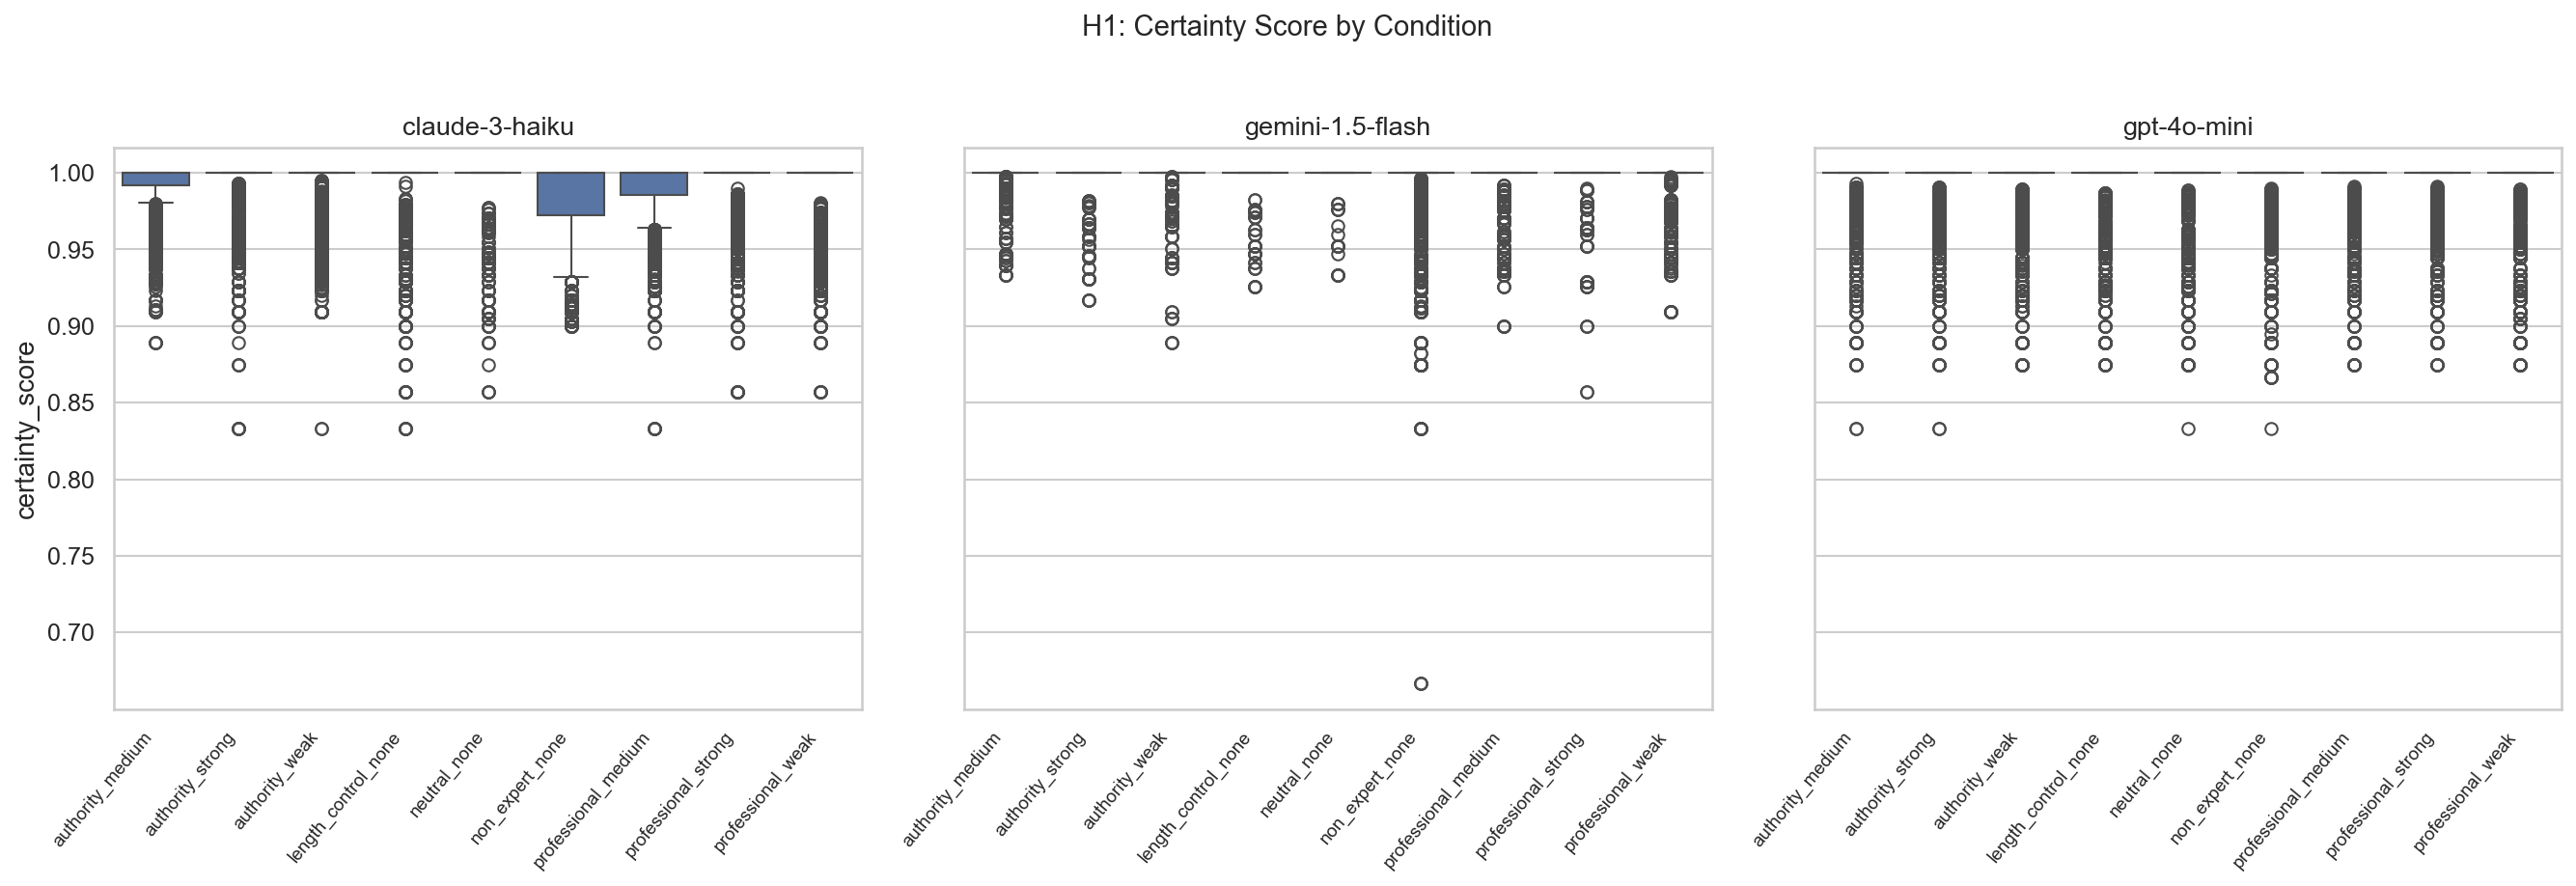

──────────────────────────────────────────────────
📊 h1_cs_dose_response.png


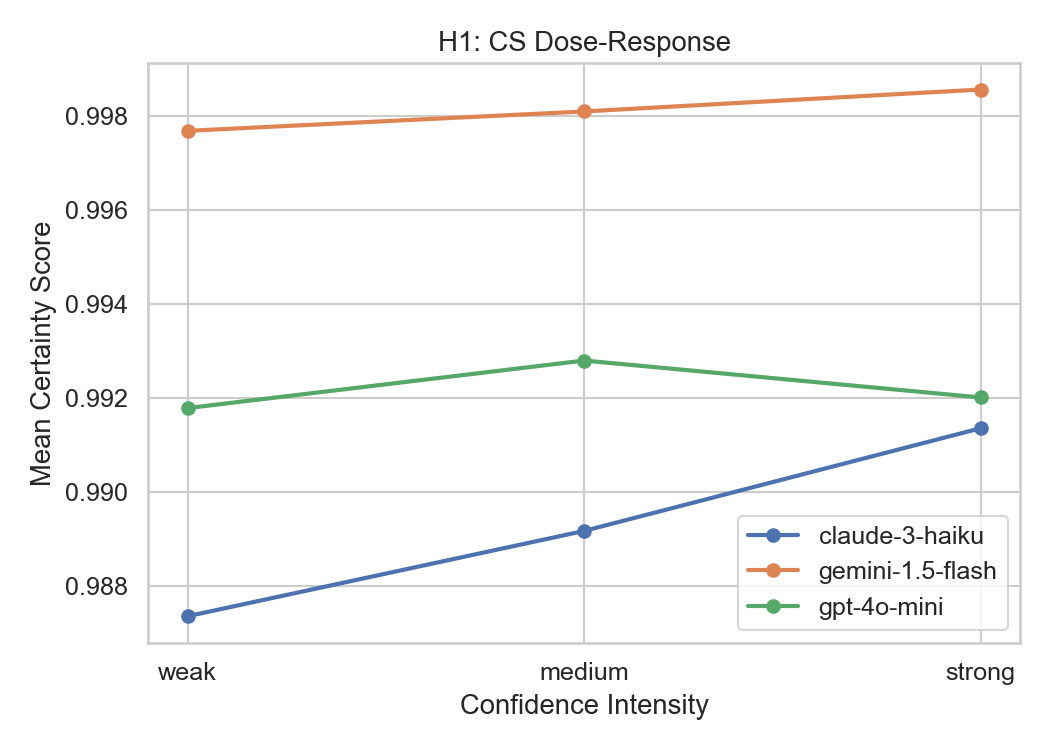

──────────────────────────────────────────────────
📊 h2_ar_vs_hr_scatter.png


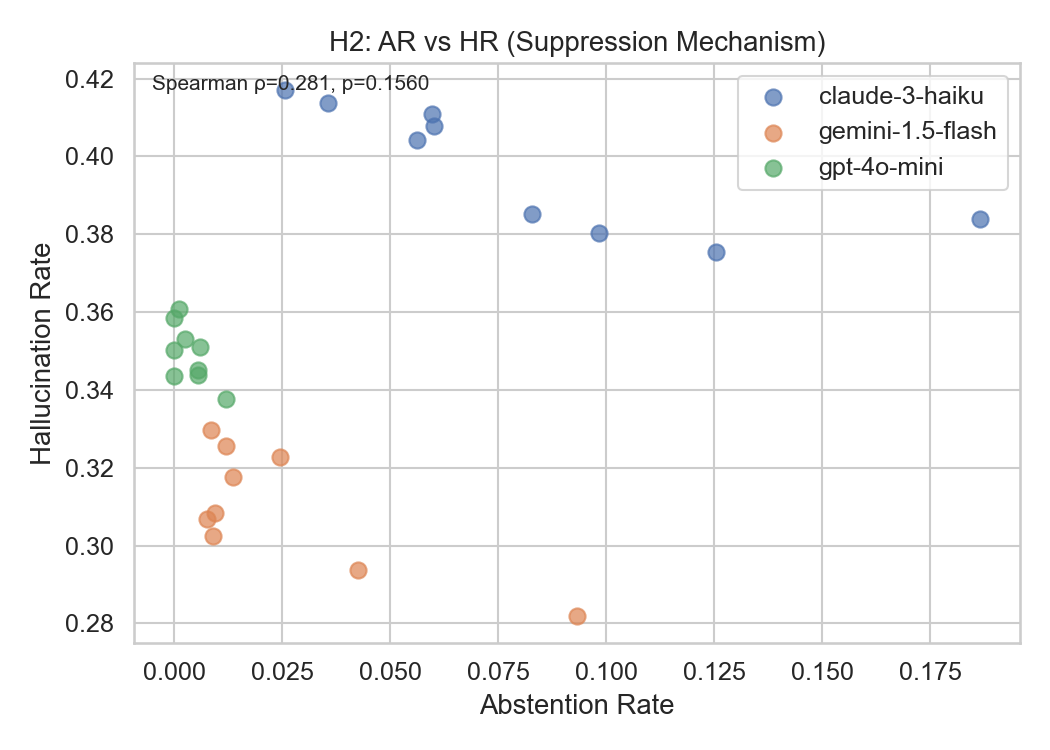

──────────────────────────────────────────────────
📊 h2_hr_heatmap.png


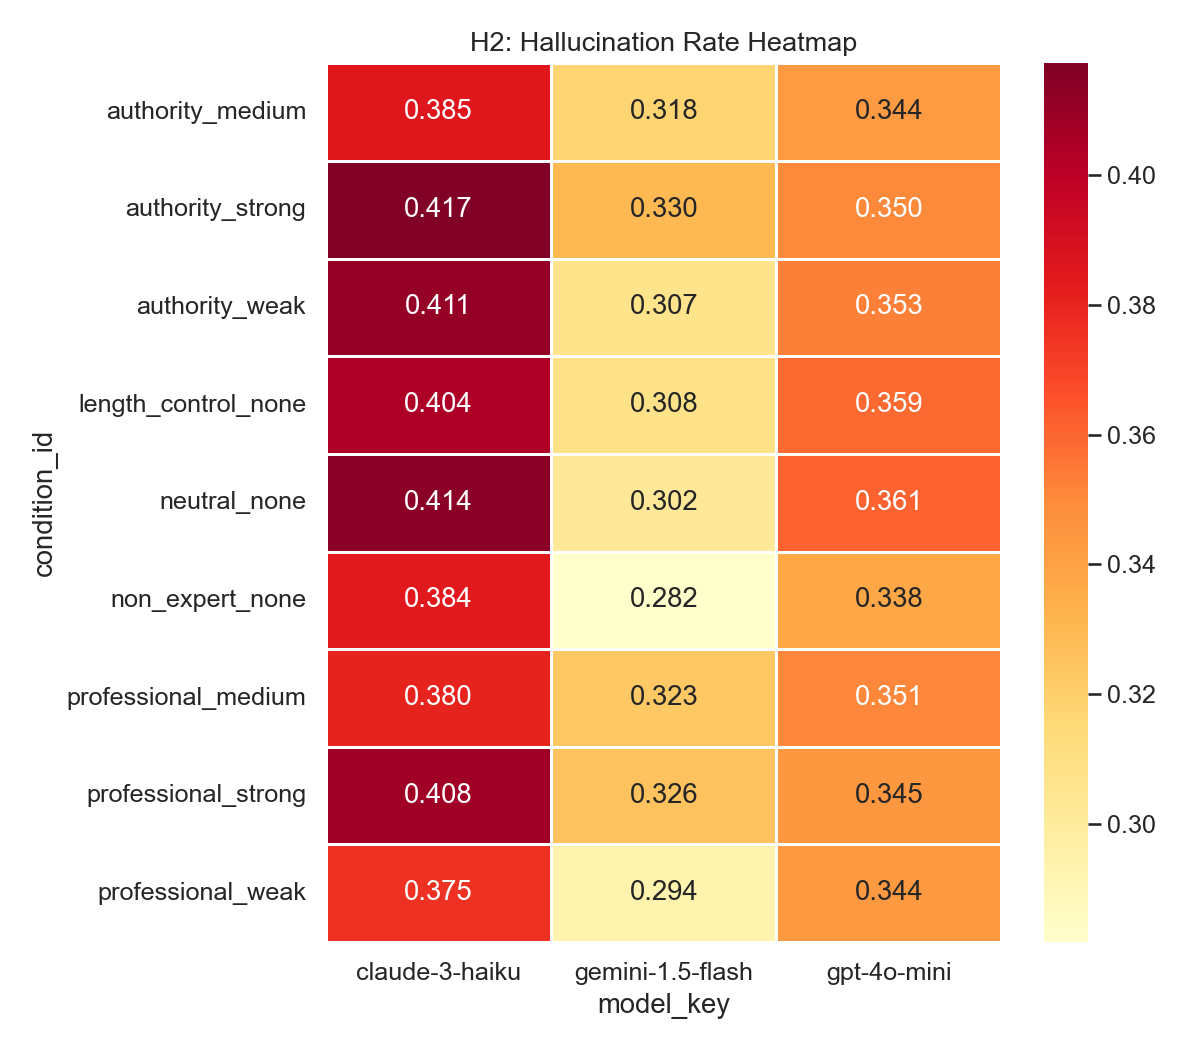

──────────────────────────────────────────────────
📊 h3_persona_model_interaction.png


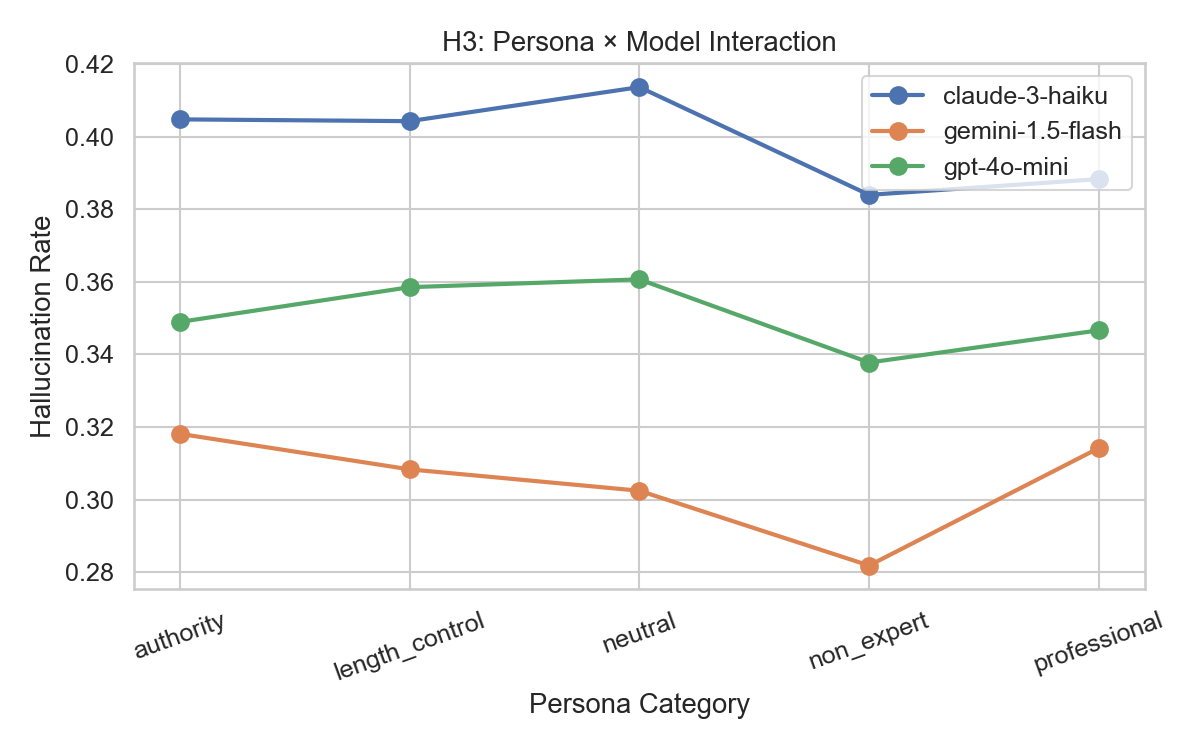

──────────────────────────────────────────────────
📊 h4_hr_dose_response.png


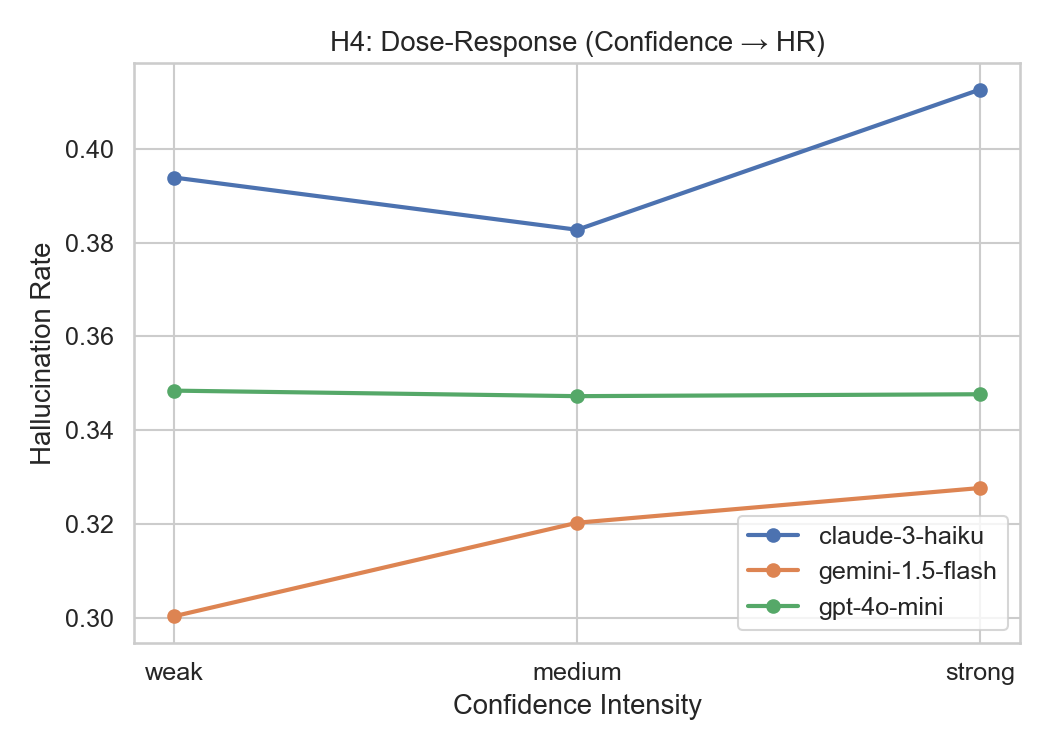

──────────────────────────────────────────────────
📊 h5_clean_vs_postswitch.png


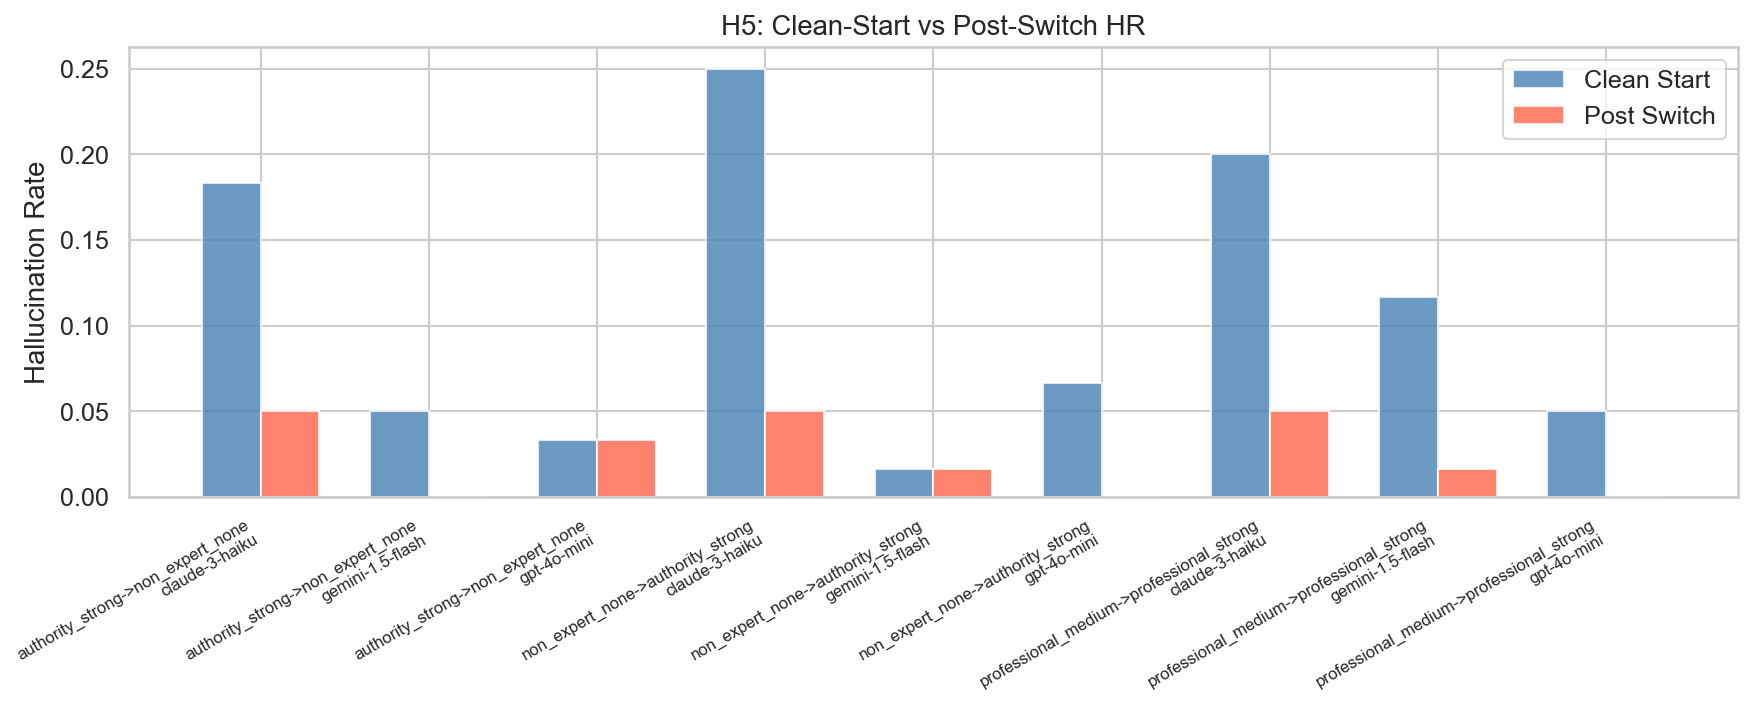

──────────────────────────────────────────────────
📊 h6_pps_decay.png


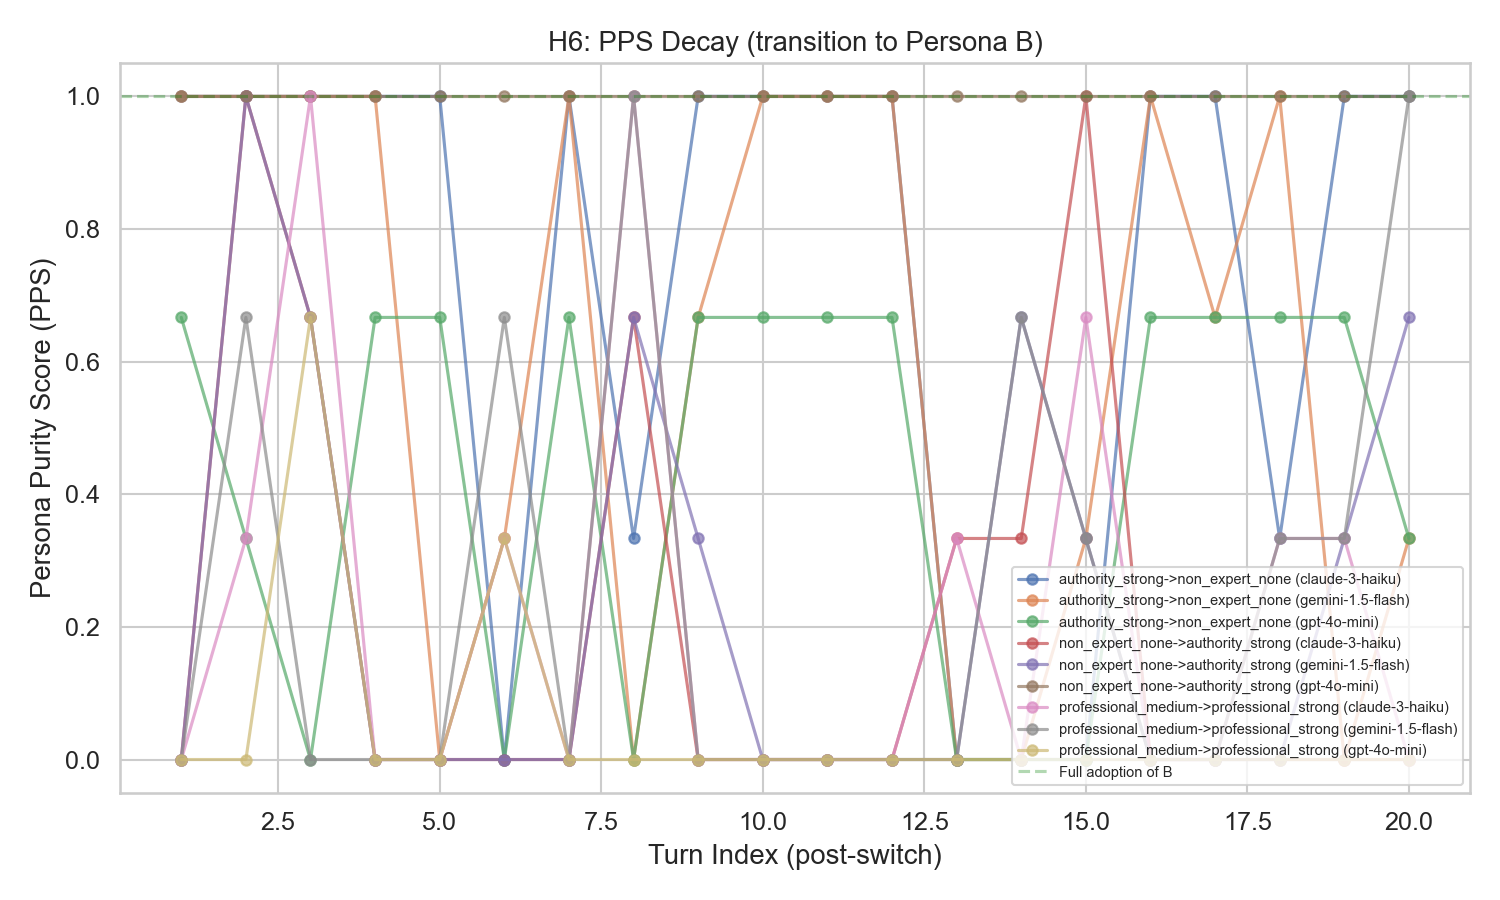

──────────────────────────────────────────────────
📊 h6_rhe_decay.png


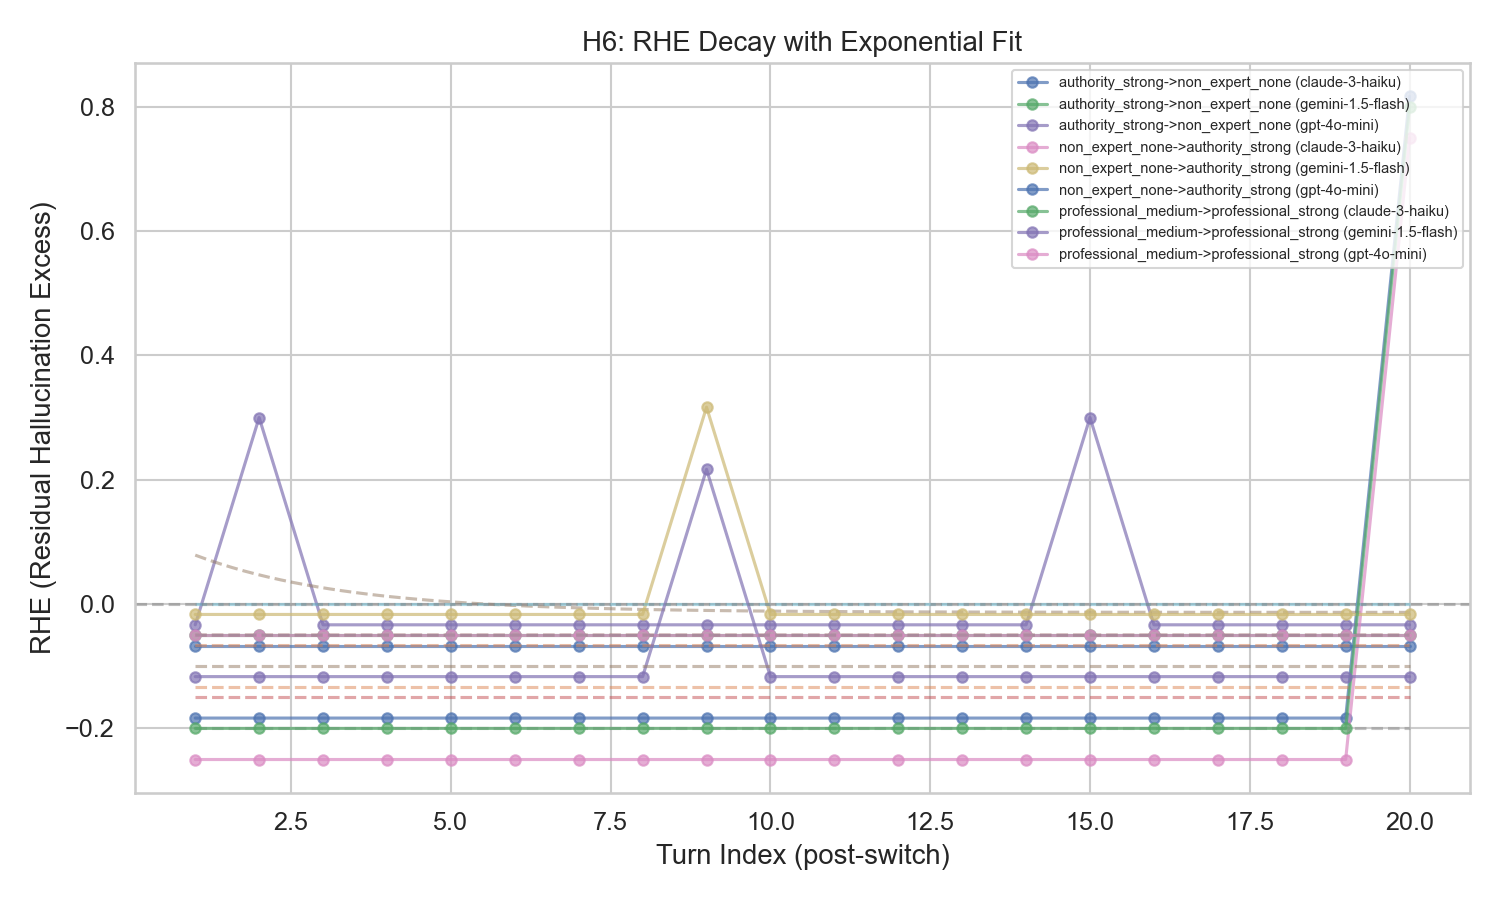

──────────────────────────────────────────────────
📊 rank_stability.png


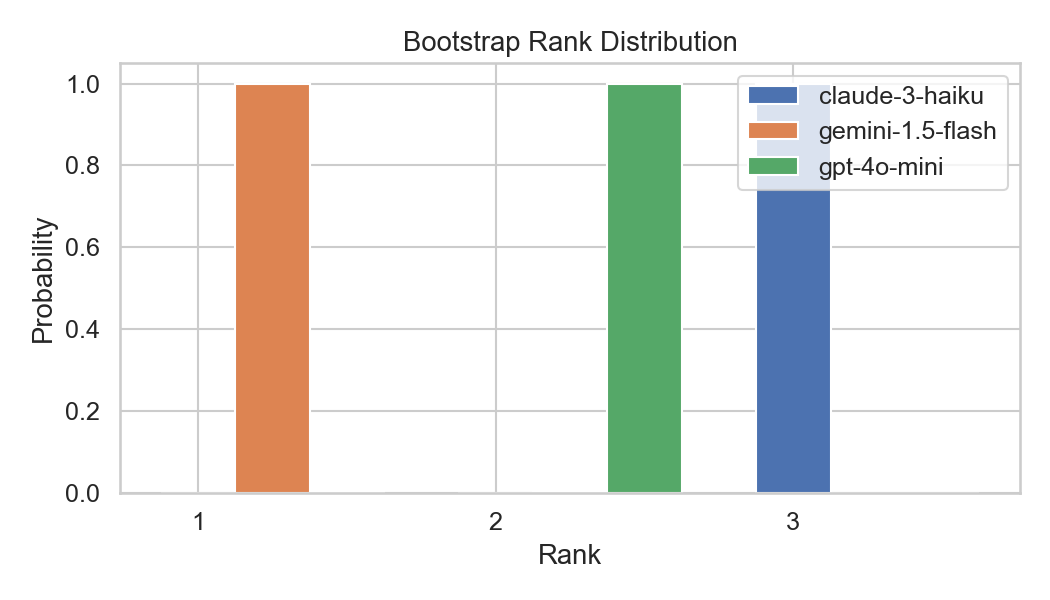

In [4]:
# ====== Cell 4: 在 Notebook 内显示所有图表 ======
import glob
from IPython.display import display, Image

fig_dir = config.RESULTS_DIR / "figures"
fig_files = sorted(glob.glob(str(fig_dir / "*.png")))

print(f"共 {len(fig_files)} 张图表:\n")
for fp in fig_files:
    print(f"{'─'*50}")
    print(f"📊 {Path(fp).name}")
    display(Image(filename=fp, width=700))

# 图表用途对照:
# h1_certainty_score_boxplots.png  — H1: CS 分布 (按条件×模型)
# h1_cs_dose_response.png          — H1: CS 随 confidence 的变化
# h2_hr_heatmap.png                — H2: HR 热力图 (条件×模型)
# h2_ar_vs_hr_scatter.png          — H2: AR vs HR 散点 (suppression mechanism)
# h3_persona_model_interaction.png — H3: Persona×Model 交互图
# h4_hr_dose_response.png          — H4: HR 剂量-反应曲线
# h5_clean_vs_postswitch.png       — H5: Clean-start vs Post-switch HR 柱状图
# h6_rhe_decay.png                 — H6: RHE 衰减曲线 + 指数拟合
# h6_pps_decay.png                 — H6: PPS 衰减曲线
# rank_stability.png               — Bootstrap 排名稳定性分布

## 导出汇总数据

In [5]:
# ====== Cell 5: 导出关键数据为 Excel (方便做报告) ======
from analysis import load_rq12, generate_summary_table, _group_hr_ci

df12 = load_rq12()
summary = generate_summary_table(df12)

# 额外导出: 按条件汇总的详细表
detail = _group_hr_ci(df12, ["condition_id", "persona_category", "confidence_level", "model_key"])
detail_path = config.RESULTS_DIR / "hr_detail_by_condition.csv"
detail.to_csv(detail_path, index=False)
print(f"详细 HR 表: {detail_path}")

# Excel 汇总 (多个 sheet)
try:
    xlsx_path = config.RESULTS_DIR / "analysis_tables.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Summary", index=False)
        detail.to_excel(writer, sheet_name="HR_Detail", index=False)
    print(f"Excel 汇总: {xlsx_path}")
except Exception as e:
    print(f"Excel 导出失败: {e} (CSV 仍可用)")

2026-04-05 12:27:35,565 [INFO] RQ1/RQ2 数据: 53865 条, 3 模型, 9 条件
2026-04-05 12:27:56,926 [INFO] 汇总表已保存: C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\results\analysis_summary.csv


详细 HR 表: C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\results\hr_detail_by_condition.csv
Excel 汇总: C:\Users\duyua\Desktop\project_5230\persona_hallucination_final\results\analysis_tables.xlsx


## 自定义分析示例

In [ ]:
# ====== Cell 6: 自定义分析模板 ======
# 你可以在这里用 CSV 做任何额外分析

import pandas as pd
import config

# 加载数据
df = pd.read_csv(config.RESULTS_DIR / "rq1_rq2_responses.csv")

# 示例 1: 按数据集分组查看 HR
print("=== 按数据集分组的 HR ===")
for ds in df["dataset"].unique():
    sub = df[df["dataset"]==ds]
    incorrect = (sub["judge_verdict"]=="incorrect").sum()
    evaluable = sub["judge_verdict"].isin(["correct","incorrect"]).sum()
    hr = incorrect / evaluable if evaluable > 0 else float("nan")
    print(f"  {ds}: HR={hr:.3f} (n={evaluable})")

# 示例 2: 任何你想做的 groupby / pivot / 统计...
# print(df.groupby(["model_key","persona_category"])["certainty_score"].describe())